In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kwant

from pathlib import Path
from scipy.sparse.linalg import eigsh
from scipy.optimize import minimize_scalar


FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

In [2]:
# Three-hopping square-octagon parameters (Energies in meV)

t_sq = 2678.0
t_link = 2980.0
t_diag = 548.0

Delta = 50.0

eps_d = 500.0
V = 800.0

target_band = 1

In [3]:
def H_oct_k(k1, k2):

    return -np.array([
        [0, t_sq, t_diag + t_link * np.exp(-1j * k2), t_sq],
        [t_sq, 0, t_sq, t_diag + t_link * np.exp(-1j * k1)],
        [t_diag + t_link * np.exp(1j * k2), t_sq, 0, t_sq],
        [t_sq, t_diag + t_link * np.exp(1j * k1), t_sq, 0]
    ], dtype=complex)

In [4]:
Nk = 181
eta_mu = 20.0

kvals = np.linspace(-np.pi, np.pi, Nk, endpoint=False)

band_energies = []

for k1 in kvals:
    for k2 in kvals:
        evals = np.linalg.eigvalsh(H_oct_k(k1, k2))
        band_energies.append(evals[target_band])

band_energies = np.array(band_energies)


Egrid = np.linspace(
    band_energies.min() - 150,
    band_energies.max() + 150,
    1600
)

diff = Egrid[:, None] - band_energies[None, :]

dos = np.exp(
    -0.5 * (diff / eta_mu)**2
).sum(axis=1)

mu_star = Egrid[np.argmax(dos)]

print(f"mu_star = {mu_star:.2f} meV")
print(f"mu_star/t_sq = {mu_star/t_sq:.4f}")

mu_star = -2416.64 meV
mu_star/t_sq = -0.9024


In [5]:
Gamma = np.array([0.0, 0.0])
X = np.array([np.pi, 0.0])
M = np.array([np.pi, np.pi])

nseg = 180

path_GX = np.linspace(Gamma, X, nseg, endpoint=False)
path_XM = np.linspace(X, M, nseg, endpoint=False)
path_MG = np.linspace(M, Gamma, nseg + 1)

k_path = np.vstack([path_GX, path_XM, path_MG])


kdist = np.zeros(len(k_path))

for i in range(1, len(k_path)):
    kdist[i] = kdist[i - 1] + np.linalg.norm(
        k_path[i] - k_path[i - 1]
    )


ix_X = len(path_GX)
ix_M = len(path_GX) + len(path_XM)

hs_x = [
    kdist[0],
    kdist[ix_X],
    kdist[ix_M],
    kdist[-1]
]

hs_labels = [
    r"$\Gamma$",
    r"$X$",
    r"$M$",
    r"$\Gamma$"
]

In [6]:
sub_index = {
    "A": 0,
    "B": 1,
    "C": 2,
    "D": 3
}


TOP_BLOCH = [
    (0, 0, "A")
]

SQUARE_BLOCH = [
    (0, 0, "A"),
    (0, 0, "B"),
    (0, 0, "C"),
    (0, 0, "D")
]

OCTAGON_BLOCH = [
    (0, 0, "D"),
    (1, 0, "B"),
    (1, 0, "A"),
    (1, 1, "C"),
    (1, 1, "B"),
    (0, 1, "D"),
    (0, 1, "C"),
    (0, 0, "A")
]

In [7]:
def bloch_channel_weight(u, k1, k2, cluster):

    Nc = len(cluster)
    amp = 0.0j

    for j, (ix, iy, sub) in enumerate(cluster):

        alpha = 1.0 / np.sqrt(Nc)
        phase = np.exp(1j * (ix * k1 + iy * k2))

        amp += np.conj(alpha) * phase * u[sub_index[sub]]

    return np.abs(amp)**2

In [8]:
P_top = []
P_square = []
P_octagon = []


for k1, k2 in k_path:

    evals, evecs = np.linalg.eigh(H_oct_k(k1, k2))
    u = evecs[:, target_band]

    P_top.append(
        bloch_channel_weight(u, k1, k2, TOP_BLOCH)
    )

    P_square.append(
        bloch_channel_weight(u, k1, k2, SQUARE_BLOCH)
    )

    P_octagon.append(
        bloch_channel_weight(u, k1, k2, OCTAGON_BLOCH)
    )


P_top = np.array(P_top)
P_square = np.array(P_square)
P_octagon = np.array(P_octagon)

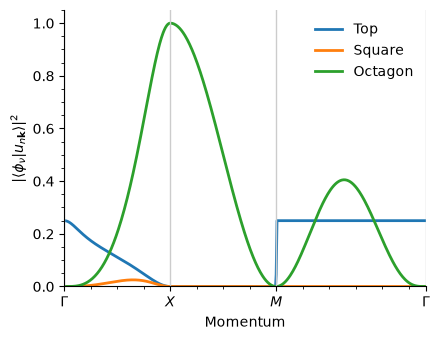

In [9]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(kdist, P_top, lw=2, label="Top")
ax.plot(kdist, P_square, lw=2, label="Square")
ax.plot(kdist, P_octagon, lw=2, label="Octagon")

for x in hs_x:
    ax.axvline(x, color="0.8", lw=1)

ax.set_xticks(hs_x)
ax.set_xticklabels(hs_labels)

ax.set_xlim(hs_x[0], hs_x[-1])
ax.set_ylim(bottom=0)

ax.set_xlabel("Momentum")
ax.set_ylabel(r"$|\langle\phi_\nu|u_{n\mathbf{k}}\rangle|^2$")

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "octagraphene_channel_overlap.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [10]:
s0 = np.eye(2, dtype=complex)

sy = np.array([
    [0, -1j],
    [1j, 0]
], dtype=complex)

sz = np.array([
    [1, 0],
    [0, -1]
], dtype=complex)

z2 = np.zeros((2, 2), dtype=complex)


rt2 = np.sqrt(2)
a = 1 + rt2


lat = kwant.lattice.general(
    [(a, 0), (0, a)],
    [
        (0, 1 / rt2),
        (-1 / rt2, 0),
        (0, -1 / rt2),
        (1 / rt2, 0)
    ],
    norbs=4
)

A, B, C, D = lat.sublattices


ad_lat = kwant.lattice.general(
    [(a, 0), (0, a)],
    [(0, 0)],
    norbs=4
)

AD = ad_lat.sublattices[0]

In [11]:
def onsite_host(site, mu, Delta):

    h = -mu * s0
    pair = 1j * Delta * sy

    return np.block([
        [h, pair],
        [pair.conj().T, -h.T]
    ])


def onsite_adatom(site, eps_d, Jd):

    h = eps_d * s0 + Jd * sz

    return np.block([
        [h, z2],
        [z2, -h.T]
    ])


def hopping_bdg(he):

    return np.block([
        [he, z2],
        [z2, -he.conj()]
    ])


def hop_square(site1, site2, t_sq):
    return hopping_bdg(-t_sq * s0)


def hop_link(site1, site2, t_link):
    return hopping_bdg(-t_link * s0)


def hop_diag(site1, site2, t_diag):
    return hopping_bdg(-t_diag * s0)

In [12]:
def build_adatom_system(Nx, Ny, geometry, V):

    syst = kwant.Builder()

    # Host sites
    for ix in range(Nx):
        for iy in range(Ny):
            syst[A(ix, iy)] = onsite_host
            syst[B(ix, iy)] = onsite_host
            syst[C(ix, iy)] = onsite_host
            syst[D(ix, iy)] = onsite_host

    # Host hoppings
    for ix in range(Nx):
        for iy in range(Ny):

            # Square edges
            syst[A(ix, iy), B(ix, iy)] = hop_square
            syst[B(ix, iy), C(ix, iy)] = hop_square
            syst[C(ix, iy), D(ix, iy)] = hop_square
            syst[D(ix, iy), A(ix, iy)] = hop_square

            # Inter-square links with PBC
            syst[C(ix, iy), A(ix, (iy + 1) % Ny)] = hop_link
            syst[B(ix, iy), D((ix + 1) % Nx, iy)] = hop_link

            # Diagonal hopping
            syst[A(ix, iy), C(ix, iy)] = hop_diag
            syst[B(ix, iy), D(ix, iy)] = hop_diag

    # Adsorption geometry
    if geometry == "Top":
        cluster = [A(0, 0)]

    elif geometry == "Square":
        cluster = [
            A(0, 0), B(0, 0),
            C(0, 0), D(0, 0)
        ]

    elif geometry == "Octagon":
        cluster = [
            D(0, 0), B(1, 0),
            A(1, 0), C(1, 1),
            B(1, 1), D(0, 1),
            C(0, 1), A(0, 0)
        ]

    else:
        raise ValueError("geometry must be Top, Square, or Octagon")

    # Adatom
    ad_site = AD(0, 0)
    syst[ad_site] = onsite_adatom

    # Symmetric adsorption channel
    Nc = len(cluster)
    hyb = hopping_bdg((V / np.sqrt(Nc)) * s0)

    for host_site in cluster:
        syst[ad_site, host_site] = hyb

    return syst.finalized(), ad_site

In [13]:
def near_zero_state(fsyst, params):

    H = fsyst.hamiltonian_submatrix(
        params=params,
        sparse=True
    )

    vals, vecs = eigsh(
        H, k=10,
        sigma=1e-7, which="LM",
        tol=1e-9, maxiter=60000
    )

    index = np.argmin(np.abs(vals))

    return vals[index].real, vecs[:, index]


def bound_energy(fsyst, params, Jd):

    p = dict(params)
    p["Jd"] = Jd

    E, _ = near_zero_state(fsyst, p)

    return abs(E)


def find_crossing(fsyst, params, J_grid):

    Egrid = np.array([
        bound_energy(fsyst, params, J)
        for J in J_grid
    ])

    i = np.argmin(Egrid)

    lo = J_grid[max(0, i - 1)]
    hi = J_grid[min(len(J_grid) - 1, i + 1)]

    result = minimize_scalar(
        lambda J: bound_energy(fsyst, params, J),
        bounds=(lo, hi),
        method="bounded",
        options={"xatol": 1e-3}
    )

    Jstar = result.x

    p = dict(params)
    p["Jd"] = Jstar

    E, vec = near_zero_state(fsyst, p)

    return Jstar, E, vec

In [14]:
Nx_bdg = 12
Ny_bdg = 8

geometries = ["Top", "Square", "Octagon"]


systems = {}

for geometry in geometries:
    systems[geometry] = build_adatom_system(
        Nx=Nx_bdg, Ny=Ny_bdg,
        geometry=geometry, V=V
    )


params = {
    "mu": mu_star,
    "Delta": Delta,
    "t_sq": t_sq,
    "t_link": t_link,
    "t_diag": t_diag,
    "eps_d": eps_d,
    "Jd": 0.0
}

In [15]:
J_values = np.linspace(0.0, 2200.0, 70)


E_top = np.array([
    bound_energy(systems["Top"][0], params, J)
    for J in J_values
])

E_square = np.array([
    bound_energy(systems["Square"][0], params, J)
    for J in J_values
])

E_octagon = np.array([
    bound_energy(systems["Octagon"][0], params, J)
    for J in J_values
])

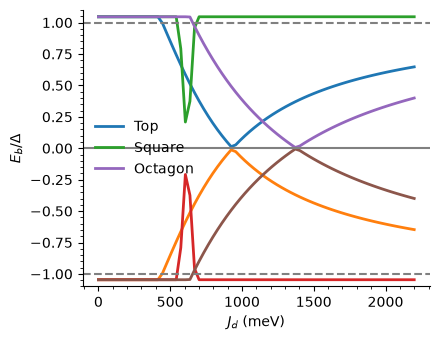

In [16]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))


ax.plot(J_values, +E_top / Delta, lw=2, label="Top")
ax.plot(J_values, -E_top / Delta, lw=2)

ax.plot(J_values, +E_square / Delta, lw=2, label="Square")
ax.plot(J_values, -E_square / Delta, lw=2)

ax.plot(J_values, +E_octagon / Delta, lw=2, label="Octagon")
ax.plot(J_values, -E_octagon / Delta, lw=2)


ax.axhline(1, color="gray", ls="--")
ax.axhline(-1, color="gray", ls="--")
ax.axhline(0, color="gray")


ax.set_xlabel(r"$J_d$ (meV)")
ax.set_ylabel(r"$E_b/\Delta$")

ax.set_ylim(-1.10, 1.10)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "octagraphene_bound_states.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()

In [17]:
Jc = {}
Wd = {}


for geometry in geometries:

    fsyst, ad_site = systems[geometry]

    Jstar, E, vec = find_crossing(
        fsyst, params,
        J_values
    )

    iad = fsyst.id_by_site[ad_site]
    ad_slice = slice(4 * iad, 4 * iad + 4)

    weight = np.sum(
        np.abs(vec[ad_slice])**2
    ).real

    Jc[geometry] = Jstar
    Wd[geometry] = weight

    print(
        f"{geometry:8s}  "
        f"Jc = {Jstar:.2f} meV   "
        f"W_d = {weight:.4f}   "
        f"W_host = {1-weight:.4f}"
    )

Top       Jc = 934.62 meV   W_d = 0.0628   W_host = 0.9372
Square    Jc = 617.20 meV   W_d = 0.9147   W_host = 0.0853
Octagon   Jc = 1379.05 meV   W_d = 0.0383   W_host = 0.9617


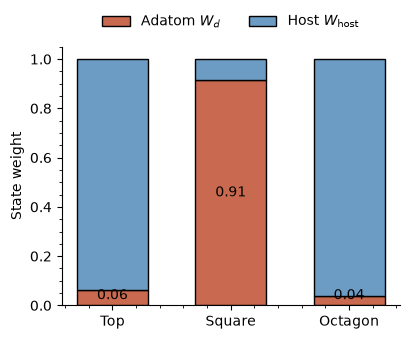

In [18]:
Wd_values = np.array([
    Wd["Top"],
    Wd["Square"],
    Wd["Octagon"]
])

Whost_values = 1.0 - Wd_values

x = np.arange(3)


fig, ax = plt.subplots(figsize=(4.2, 3.5))


ax.bar(
    x, Wd_values,
    width=0.60,
    color="#C96A50",
    edgecolor="black",
    label=r"Adatom $W_d$"
)

ax.bar(
    x, Whost_values,
    width=0.60,
    bottom=Wd_values,
    color="#6C9BC3",
    edgecolor="black",
    label=r"Host $W_{\rm host}$"
)


ax.set_xticks(x)
ax.set_xticklabels(geometries)

ax.set_ylabel("State weight")
ax.set_ylim(0, 1.05)


for i, w in enumerate(Wd_values):
    ax.text(
        i, max(0.04, w / 2),
        f"{w:.2f}",
        ha="center", va="center"
    )


ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=2,
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.minorticks_on()

plt.tight_layout()

# plt.savefig(
#     FIG_DIR / "octagraphene_state_character.pdf",
#     dpi=600, bbox_inches="tight"
# )

plt.show()